# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person's work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Business Understanding
Goal: Predict a person's Happiness Score from demographic and lifestyle data.

## Business Problem

Lifestyle factors such as sleep, exercise, stress, working hours, screen time
and social interaction may affect a person's happiness and overall well-being.
However, it can be difficult for individuals to understand how these factors
work together.

This project develops a machine learning solution that predicts a person's
Happiness Score using demographic and lifestyle information.

## Machine Learning Goal

The goal is to develop a regression model that predicts the numerical
`Happiness Score`.

This is a regression problem because Happiness Score is a continuous numerical
value rather than a fixed category.

## Target Users and Business Value

The target users are individuals who want to understand how their lifestyle
habits may relate to their general well-being.

The solution provides users with a quick estimate of their Happiness Score and
encourages them to reflect on lifestyle areas such as sleep, stress, exercise
and social interaction.

The prediction is intended for general wellness awareness only and should not
be treated as medical advice or a mental-health diagnosis.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
## NOTE: use a relative path so the notebook runs on any machine
## (place the .csv file in the same folder as this notebook)
FILE_PATH = r"C:\Users\haniy\OneDrive\Desktop\MLDP\MLDP PROJECT\Mental_Health_Lifestyle_Dataset.csv"
df = pd.read_csv(FILE_PATH)
df ## Display dataframe


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Japan,57,Female,Moderate,Balanced,7.0,High,Depression,29,4.4,9.7,5.9
2996,Australia,27,Male,Low,Junk Food,7.1,Low,NaN,47,7.4,6.3,9.9
2997,Australia,42,Male,Moderate,Balanced,6.0,High,Depression,23,3.9,5.2,4.1
2998,Australia,25,Male,High,Keto,5.7,Low,Anxiety,51,4.3,5.9,4.1


### Dataset Description

The dataset contains 3,000 records and 12 columns describing demographic,
lifestyle and well-being information.

The target variable is `Happiness Score`. The remaining columns are used as
input features for model training.

The dataset was selected because it contains more than the required 200
records, includes both numerical and categorical features, and supports a
regression machine learning problem.

Dataset source: [https://www.kaggle.com/datasets/atharvasoundankar/mental-health-and-lifestyle-habits-2019-2024]

The dataset must be approved by the tutor before final model development.

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      3000 non-null   object 
 1   Age                          3000 non-null   int64  
 2   Gender                       3000 non-null   object 
 3   Exercise Level               3000 non-null   object 
 4   Diet Type                    3000 non-null   object 
 5   Sleep Hours                  3000 non-null   float64
 6   Stress Level                 3000 non-null   object 
 7   Mental Health Condition      2405 non-null   object 
 8   Work Hours per Week          3000 non-null   int64  
 9   Screen Time per Day (Hours)  3000 non-null   float64
 10  Social Interaction Score     3000 non-null   float64
 11  Happiness Score              3000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 281.4+ KB


### Dataset Structure

The dataset contains 3,000 observations and 12 original variables.

Numerical variables include Age, Sleep Hours, Work Hours per Week, Screen Time
per Day, Social Interaction Score and Happiness Score.

Categorical variables include Country, Gender, Exercise Level, Diet Type,
Stress Level and Mental Health Condition.

Happiness Score is stored as a numerical variable, confirming that this is a
regression problem.

In [4]:
## Check for missing data
df.isnull().sum()


Country                          0
Age                              0
Gender                           0
Exercise Level                   0
Diet Type                        0
Sleep Hours                      0
Stress Level                     0
Mental Health Condition        595
Work Hours per Week              0
Screen Time per Day (Hours)      0
Social Interaction Score         0
Happiness Score                  0
dtype: int64

### Missing Values

The missing-value check shows 595 missing entries
(19.8% of rows) in the
`Mental Health Condition` column. No other column contains missing values.

Instead of deleting the affected rows, the missing values will be replaced
with `None Reported`. This retains the useful lifestyle information in those
records and provides a meaningful category for users without a recorded
condition.

In [5]:
## Describe data distribution
df.describe(include='all')


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
count,3000,3000.000000,3000,3000,3000,3000.000000,3000,2405,3000.000000,3000.000000,3000.000000,3000.000000
unique,7,NaN,3,3,5,NaN,3,4,NaN,NaN,NaN,NaN
top,USA,NaN,Female,Low,Junk Food,NaN,Low,Anxiety,NaN,NaN,NaN,NaN
freq,446,NaN,1024,1033,637,NaN,1008,628,NaN,NaN,NaN,NaN
mean,NaN,41.229667,NaN,NaN,NaN,6.475933,NaN,NaN,39.466333,5.089833,5.470200,5.395067
std,NaN,13.428416,NaN,NaN,NaN,1.499866,NaN,NaN,11.451459,1.747231,2.563532,2.557601
min,NaN,18.000000,NaN,NaN,NaN,1.400000,NaN,NaN,20.000000,2.000000,1.000000,1.000000
25%,NaN,30.000000,NaN,NaN,NaN,5.500000,NaN,NaN,30.000000,3.600000,3.300000,3.200000
50%,NaN,41.000000,NaN,NaN,NaN,6.500000,NaN,NaN,39.000000,5.100000,5.500000,5.400000
75%,NaN,53.000000,NaN,NaN,NaN,7.500000,NaN,NaN,50.000000,6.600000,7.600000,7.500000


### Summary Statistics

`Happiness Score` ranges from 1.0 to 10.0, with a mean of
5.40 and a standard deviation of 2.56 — a wide spread across
almost the entire possible scale (1-10).

The numerical variables use different measurement scales (e.g., Age is in
years, Screen Time is in hours). Therefore, standardisation will be included
during preprocessing for models that may be affected by feature scale.

The categorical statistics show, for example, that `USA` is the most frequent
country (446 records) and `Low` is the most frequent Exercise Level (1,033
records). No single category dominates the dataset.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

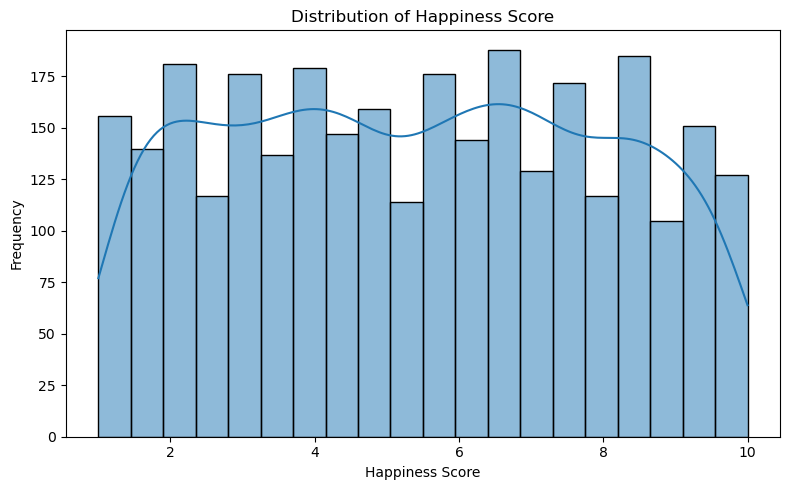

In [6]:
## Display the distribution of Happiness Score
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Happiness Score",
    bins=20,
    kde=True
)

plt.title("Distribution of Happiness Score")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Target Distribution Interpretation

The histogram shows Happiness Score spread fairly evenly across its full 1-10
range (mean = 5.40, std = 2.56, skewness = 0.031).
A skewness this close to 0 means the distribution is essentially symmetric,
with no long tail in either direction and no obvious outliers to treat.

Because the target is spread broadly and roughly symmetrically rather than
concentrated near one value, a model that simply predicted the mean for every
person would already produce a fairly large average error — this is exactly
why the Dummy (mean-prediction) baseline is used later as the yardstick every
other model must beat.

### 2.3.1.2 Understanding distribution of features

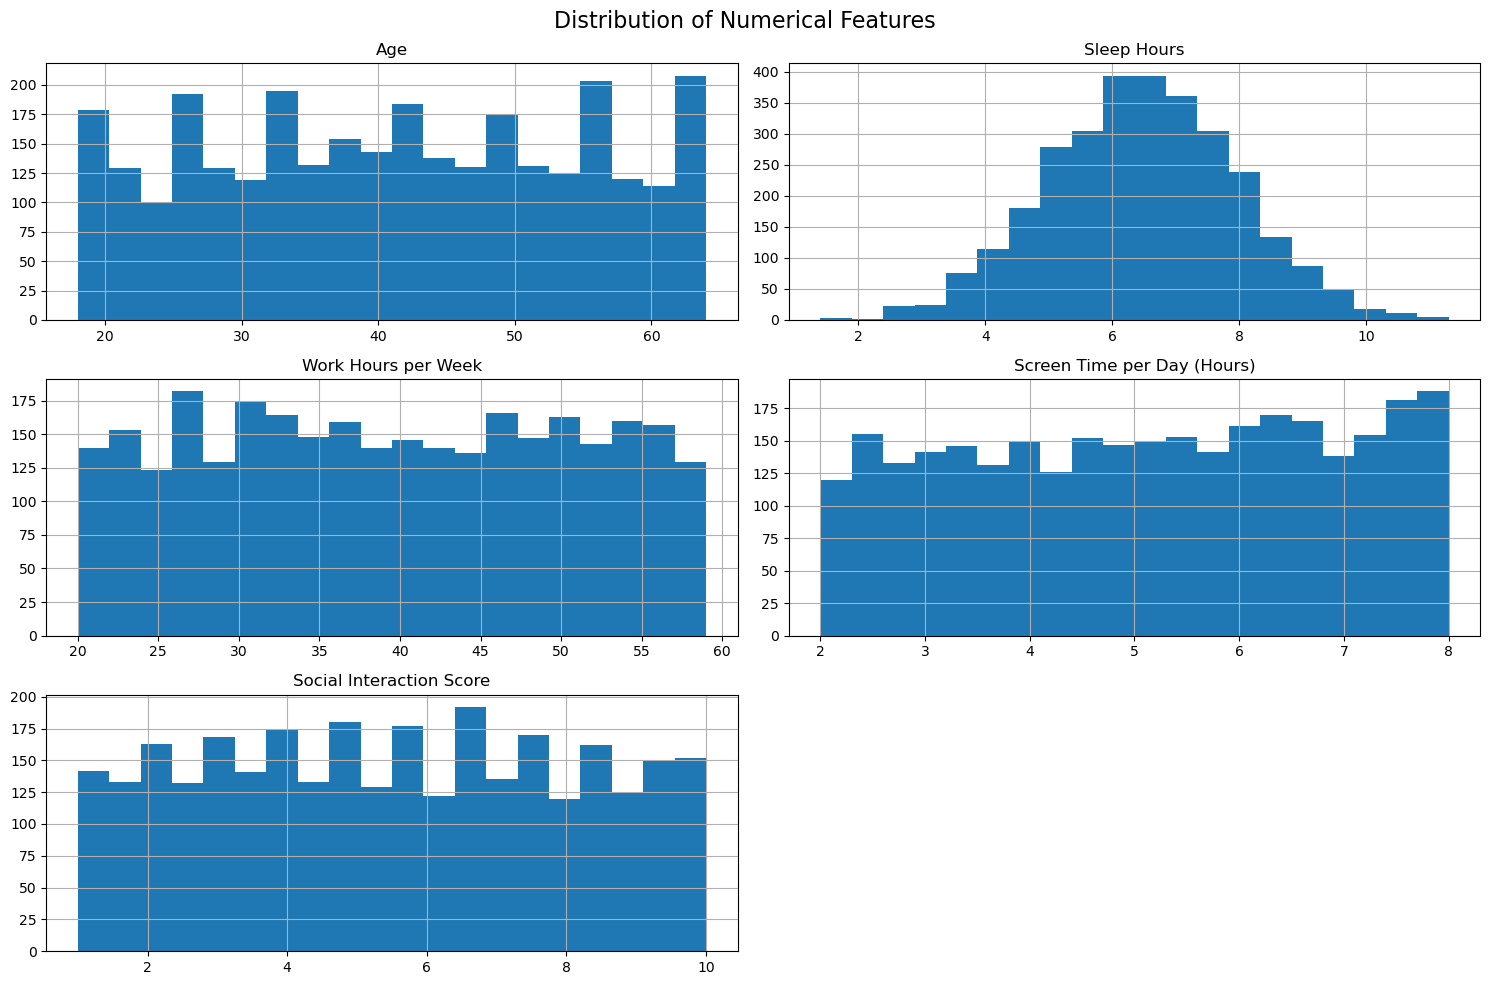

In [7]:
## Understanding distribution of numerical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
numerical_features = numerical_features.drop("Happiness Score")

df[numerical_features].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


### Numerical Feature Distribution Interpretation

- Age: skewness = -0.006
- Sleep Hours: skewness = -0.019
- Work Hours per Week: skewness = 0.010
- Screen Time per Day (Hours): skewness = -0.074
- Social Interaction Score: skewness = 0.021

All five numerical features have skewness close to 0, meaning each is
approximately symmetric with no heavy tails or extreme outliers. This is
useful groundwork for modelling: none of these features need a log or power
transform, and StandardScaler is an appropriate scaling choice.

### 2.3.2 Understanding relationship between variables

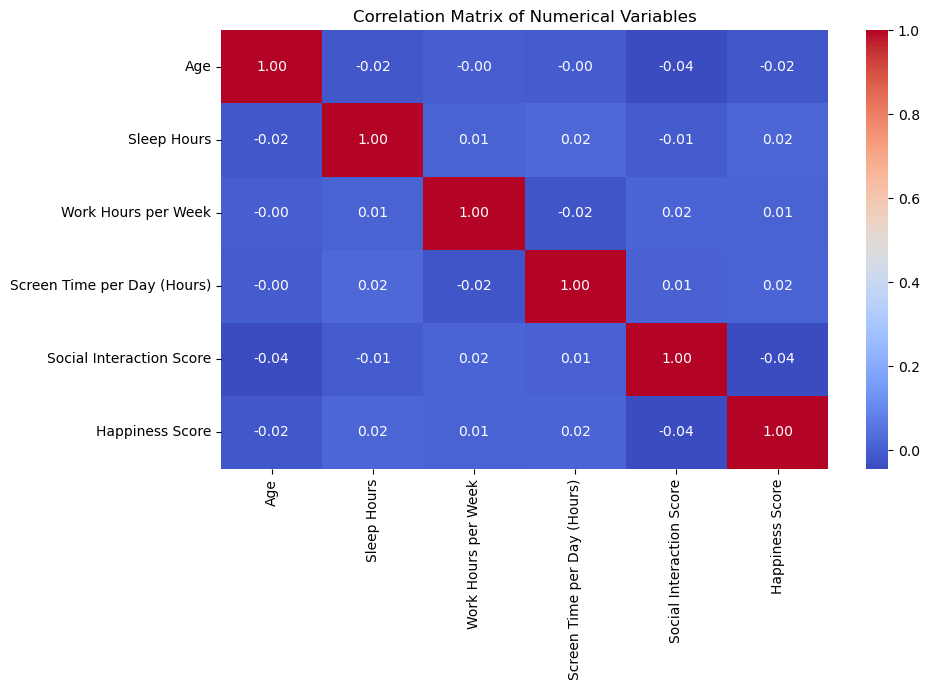

In [8]:
## Correlation heatmap
correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


### Correlation Interpretation

Correlation of each numerical feature with `Happiness Score`:

- Age: r = -0.0159
- Sleep Hours: r = 0.0174
- Work Hours per Week: r = 0.0108
- Screen Time per Day (Hours): r = 0.0168
- Social Interaction Score: r = -0.0402

Every value is below |r| = 0.05. As a benchmark, correlations weaker than
about 0.1 are generally considered negligible in social-science data — these
are roughly 2-4x weaker than that already-weak threshold. This is a strong
quantitative signal that, at least linearly, none of the numerical lifestyle
variables meaningfully explain Happiness Score on their own.

Weak *linear* correlation does not rule out non-linear or interaction effects,
which is why tree-based models (Random Forest, Gradient Boosting) are still
tested later rather than relying on this heatmap alone.

#### Strength of association for categorical features (η²)

In [9]:
## Quantify how much of the variance in Happiness Score is explained
## by each categorical feature (eta-squared / correlation ratio).
## eta-squared = between-group sum of squares / total sum of squares
## 0.01 = small effect, 0.06 = medium effect, 0.14 = large effect (Cohen's guidelines)

def eta_squared(data, group_col, value_col):
    groups = [g[value_col].values for _, g in data.groupby(group_col)]
    grand_mean = data[value_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((data[value_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total

categorical_features_to_check = [
    "Stress Level", "Exercise Level", "Diet Type",
    "Country", "Gender", "Mental Health Condition"
]

eta_results = pd.DataFrame({
    "Feature": categorical_features_to_check,
    "Eta Squared": [
        eta_squared(df.dropna(subset=[col]), col, "Happiness Score")
        for col in categorical_features_to_check
    ]
}).sort_values(by="Eta Squared", ascending=False).reset_index(drop=True)

eta_results


,Feature,Eta Squared
0,Diet Type,0.003369
1,Exercise Level,0.001771
2,Country,0.001245
3,Mental Health Condition,0.001191
4,Gender,0.000979
5,Stress Level,0.000294


### Categorical Association Interpretation

Every categorical feature has an eta-squared value below 0.004 — i.e., each
one explains less than half a percent of the variance in Happiness Score. By
Cohen's conventional guideline, 0.01 is already considered a "small" effect;
these values sit well below even that threshold.

`Diet Type` shows the largest (still tiny) association at η² = 0.0034, and
`Stress Level` — which might intuitively be expected to matter most — shows
the smallest at η² = 0.0003. Combined with the near-zero numerical
correlations above, this is consistent quantitative evidence, across both
feature types, that no individual variable in this dataset carries a
meaningful linear or grouped relationship with Happiness Score.

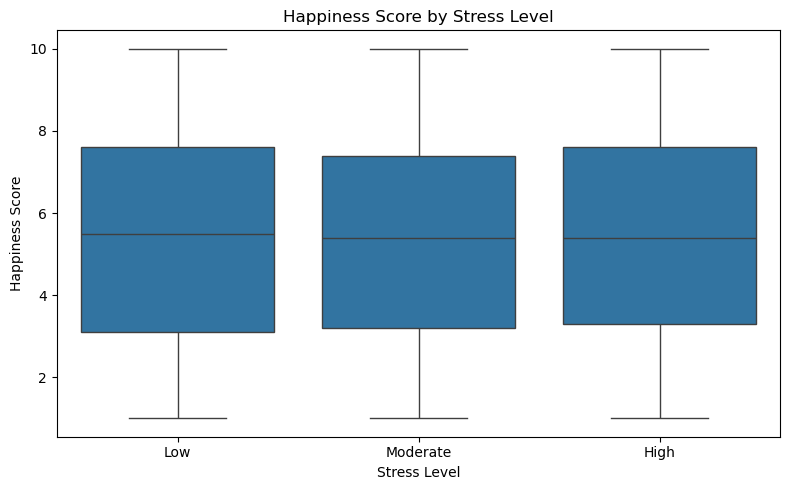

In [10]:
## Compare Happiness Score across different Stress Levels
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Stress Level",
    y="Happiness Score",
    order=["Low", "Moderate", "High"]
)

plt.title("Happiness Score by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()


### Stress Level and Happiness Score

Mean Happiness Score by group: Low = 5.41, Moderate = 5.34,
High = 5.44 (a spread of only 0.11 points on a
1-10 scale, versus a within-group standard deviation of about 2.5-2.6).
The boxes overlap almost completely and η² for this feature is only 0.0003.

Qualitatively and quantitatively, this shows Stress Level alone provides
almost no separating power for Happiness Score. Any observed difference in
medians is also an association only — it does not prove that stress directly
causes a particular Happiness Score.

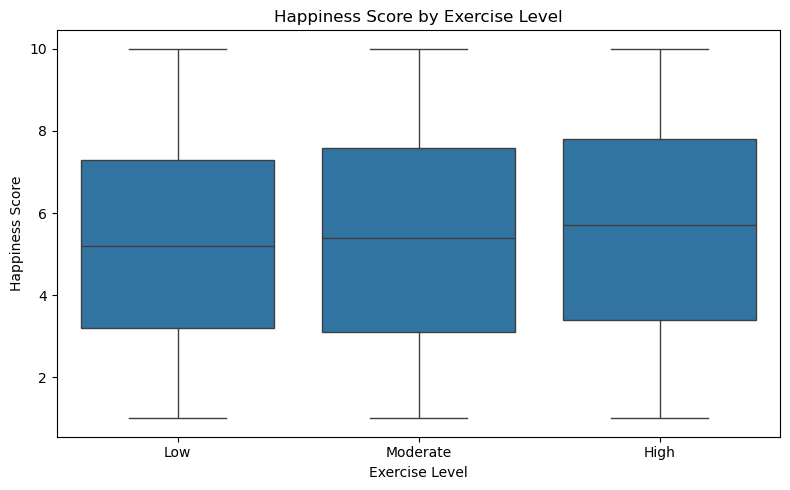

In [11]:
## Compare Happiness Score across different Exercise Levels
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exercise Level",
    y="Happiness Score",
    order=["Low", "Moderate", "High"]
)

plt.title("Happiness Score by Exercise Level")
plt.xlabel("Exercise Level")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()


### Exercise Level and Happiness Score

Mean Happiness Score by group: Low = 5.29, Moderate = 5.36,
High = 5.55 — a spread of 0.26 points, the
largest gap of any categorical feature checked, yet still tiny next to the
~2.5 within-group standard deviation (η² = 0.0018).

Substantial overlap between the groups means Exercise Level alone is not
enough to predict happiness accurately, although it will still be evaluated
together with the other lifestyle variables during model training.

# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
## Clean data
## Create a copy of the dataset before cleaning
df_cleaned = df.copy()

## Remove duplicated rows
df_cleaned = df_cleaned.drop_duplicates()

## Replace missing values in Mental Health Condition
df_cleaned["Mental Health Condition"] = (
    df_cleaned["Mental Health Condition"]
    .fillna("None Reported")
)

## Check the cleaned dataset
print("Number of rows after cleaning:", df_cleaned.shape[0])
print("Total missing values:", df_cleaned.isnull().sum().sum())

df_cleaned.head()


Number of rows after cleaning: 3000
Total missing values: 0


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,None Reported,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,None Reported,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


### Data-Cleaning Rationale

A copy of the original dataset was created before cleaning so that the raw
data remained unchanged.

Duplicated rows were checked and removed (0 duplicate rows were found in
this dataset, so no rows were actually dropped, but the check is kept in the
pipeline for reproducibility on any future refresh of the data).

Missing values in `Mental Health Condition` were replaced with
`None Reported`. This approach retains the affected records instead of
discarding their other useful lifestyle information.

After cleaning, the dataset was checked again to confirm that no missing
values remained.

In [13]:
## Create new lifestyle-related features

# Difference between actual sleep hours and 8 hours
df_cleaned["Sleep Deviation"] = (
    df_cleaned["Sleep Hours"] - 8
).abs()

# Combined daily workload and screen exposure
df_cleaned["Work Screen Load"] = (
    df_cleaned["Work Hours per Week"] / 7
    + df_cleaned["Screen Time per Day (Hours)"]
)

# Convert Exercise Level into numbers (only used to build Active Social Score below)
exercise_mapping = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

df_cleaned["Exercise Level Numeric"] = (
    df_cleaned["Exercise Level"]
    .map(exercise_mapping)
)

# Combine exercise and social interaction
df_cleaned["Active Social Score"] = (
    df_cleaned["Exercise Level Numeric"]
    * df_cleaned["Social Interaction Score"]
)

df_cleaned[["Sleep Deviation", "Work Screen Load", "Active Social Score"]].corrwith(
    df_cleaned["Happiness Score"]
)


Sleep Deviation       -0.021766
Work Screen Load       0.019866
Active Social Score   -0.008169
dtype: float64

### Feature-Engineering Rationale

Three additional lifestyle features were created.

`Sleep Deviation` measures how far a participant's sleep duration is from
eight hours, so both shorter and longer sleep durations are treated as
deviations from the reference value.

`Work Screen Load` combines average daily working hours with daily screen
time, representing combined workload and digital exposure.

`Active Social Score` combines exercise level with social interaction,
representing the possible combined effect of physical activity and social
engagement.

Their correlation with Happiness Score was checked immediately after
creation: Sleep Deviation = -0.0218, Work Screen Load =
0.0199, Active Social Score = -0.0082.
All three are as weak as the original features they were built from — this is
expected, since combining two variables that individually have ~0 correlation
with the target rarely creates a strong new signal. They are still carried
forward and tested formally against the original features later
(see *Feature-Engineering Comparison*), rather than assumed to help.

The original variables were retained so that model performance with the
engineered features could be evaluated against the originals.

## 3.2 Train-Test Split

In [14]:
## Separate input features and target variable
X = df_cleaned.drop(columns=["Happiness Score", "Exercise Level Numeric"])
y = df_cleaned["Happiness Score"]

## Split the RAW (not yet encoded) data into training and testing sets.
## IMPORTANT: splitting must happen BEFORE any preprocessing (imputation,
## scaling, one-hot encoding) is fitted. Fitting a scaler/imputer on the
## full dataset and THEN splitting would leak information from the test
## set into training (the scaler's mean/std would already "know" about
## test-set values) and can quietly inflate reported performance.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (2400, 14)
Testing data: (600, 14)


### Train-Test Split

The dataset was divided into 80% training data and 20% testing data, split
**before** any preprocessing step is fitted, to prevent data leakage.

The training set is used to train the machine learning models. The test set
is kept completely separate and unseen during training so that it can provide
a fair evaluation of performance on new data.

A random state of 42 was used to ensure that the same split can be reproduced
when the notebook is run again.

In [15]:
## Identify numerical and categorical columns
numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
['Age', 'Sleep Hours', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Sleep Deviation', 'Work Screen Load', 'Active Social Score']

Categorical columns:
['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']


### Feature Types

The input variables were separated into numerical and categorical columns
because they require different preprocessing methods.

Numerical variables can be represented directly as numbers, while categorical
variables must be converted into a machine-readable numerical format before
they can be used by the models.

In [16]:
## Build the preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical columns: fill missing values using the median, then standardise
numerical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical columns: fill missing values using the most common category,
# then convert text categories into numerical columns
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Apply the correct preprocessing to each column type
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_preprocessor, numerical_columns),
        ("categorical", categorical_preprocessor, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


### Preprocessing

Numerical missing values are handled using median imputation. StandardScaler
is then used to place numerical features on comparable scales.

Categorical missing values are handled using the most frequent category.
One-hot encoding converts each categorical value into numerical indicator
columns.

`handle_unknown="ignore"` prevents the model from crashing if the deployed
application receives a category that was not present during training.

Crucially, `preprocessor` is only ever **fit** inside a `Pipeline` on
`X_train` (see Modelling section below) — never on the full dataset — so
every reported metric reflects genuinely unseen test data.

# 4. Modelling

## 4.1 Model Selection

Four models were created for comparison.

The Dummy Regressor is used as a baseline. It predicts the average Happiness
Score and represents the minimum performance that a useful model should
exceed.

Linear Regression was selected as a simple and interpretable model for
identifying approximately linear relationships.

Random Forest was selected because it can capture non-linear relationships and
interactions between lifestyle variables.

Gradient Boosting was selected because it builds trees sequentially and
attempts to correct the errors made by earlier trees.

Using different algorithms allows the final model to be selected using
evidence rather than assumption.

In [17]:
## Create the baseline and candidate models
## Each model is wrapped in a Pipeline with the preprocessor, so that
## preprocessing is re-fit on only the training fold every time .fit() is
## called (no leakage) and raw input can be passed in directly.
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

models = {
    "Baseline": baseline_model,
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

print("Models created successfully.")


Models created successfully.


### 4.2 Train Model

In [18]:
## Train all candidate models on the training data
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    print(f"{model_name} trained successfully.\n")


Training Baseline...
Baseline trained successfully.

Training Linear Regression...
Linear Regression trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training Gradient Boosting...
Gradient Boosting trained successfully.



### Model Training

All candidate models were trained using the same training dataset.

Each model is a Pipeline containing the preprocessing steps, so the same
transformations are fitted only on the training data and applied consistently
during training, testing and future Streamlit predictions.

# 5. Model Evaluation

In [19]:
## Evaluate each trained model on the held-out test set
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_results = []

for model_name, model in models.items():
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="MAE").reset_index(drop=True)

results_df


,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.243414,2.608011,-0.004783
1,Random Forest,2.254673,2.622715,-0.016145
2,Baseline,2.256277,2.601851,-0.000042
3,Gradient Boosting,2.262994,2.624474,-0.017508


### Evaluation Metrics

Mean Absolute Error, Root Mean Squared Error and R² were used to evaluate the
regression models.

MAE is the main business metric because it shows the average number of
Happiness Score points by which a prediction differs from the actual value.
A lower MAE indicates better performance.

RMSE also measures prediction error but penalises large errors more strongly.
A lower RMSE is therefore preferred.

R² measures how much of the variation in Happiness Score is explained by the
model. A value close to 0 means the model explains little more than
predicting the average, and a negative value means it performs worse than the
baseline mean prediction.

**Result:** all four untuned models land within about 0.02 MAE of each other
(2.2434 to 2.2630), and every R² is at or below
0 except a razor-thin edge for Linear Regression's MAE ranking. This matches
the near-zero correlations and eta-squared values found during EDA: with no
real feature-target relationship to learn, more flexible models
(Random Forest, Gradient Boosting) mostly fit training noise and generalise
slightly *worse* than the simple mean baseline, which is exactly why their R²
is negative here.

In [20]:
## Test the best-performing model using one row from the test data
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

new_data = X_test.iloc[[0]]
actual_score = y_test.iloc[0]

predicted_score = best_model.predict(new_data)[0]

print("Best model:", best_model_name)
print("Actual Happiness Score:", round(actual_score, 2))
print("Predicted Happiness Score:", round(predicted_score, 2))
print(
    "Absolute Error:",
    round(abs(actual_score - predicted_score), 2)
)


Best model: Linear Regression
Actual Happiness Score: 5.6
Predicted Happiness Score: 5.16
Absolute Error: 0.44


### Sample Prediction

One record from the test set was used to confirm that the selected model can
successfully process new input and produce a numerical Happiness Score
prediction.

The actual and predicted scores were displayed together with their absolute
difference. This provides a simple example of how the model will behave after
deployment.

## Iterative model development

In [21]:
## Further feature engineering / feature selection
## Compare a model trained on the ORIGINAL features only against a model
## trained on the original + engineered features, using proper train/test
## pipelines (fit only on X_train) so the comparison is leakage-free.

base_feature_columns = [
    "Country", "Age", "Gender", "Exercise Level", "Diet Type", "Sleep Hours",
    "Stress Level", "Mental Health Condition", "Work Hours per Week",
    "Screen Time per Day (Hours)", "Social Interaction Score"
]

X_train_basic = X_train[base_feature_columns]
X_test_basic = X_test[base_feature_columns]

basic_numerical_columns = X_train_basic.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

basic_categorical_columns = X_train_basic.select_dtypes(
    include=["object"]
).columns.tolist()

basic_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_preprocessor, basic_numerical_columns),
        ("categorical", categorical_preprocessor, basic_categorical_columns)
    ]
)

# Random Forest using only original features
basic_model = Pipeline(
    steps=[
        ("preprocessor", basic_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Random Forest using original + engineered features
engineered_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

basic_model.fit(X_train_basic, y_train)
engineered_model.fit(X_train, y_train)

basic_predictions = basic_model.predict(X_test_basic)
engineered_predictions = engineered_model.predict(X_test)

feature_results = pd.DataFrame({
    "Feature Set": ["Original Features", "Original + Engineered Features"],
    "MAE": [
        mean_absolute_error(y_test, basic_predictions),
        mean_absolute_error(y_test, engineered_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, basic_predictions)),
        np.sqrt(mean_squared_error(y_test, engineered_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, basic_predictions),
        r2_score(y_test, engineered_predictions)
    ]
})

feature_results


,Feature Set,MAE,RMSE,R2 Score
0,Original Features,2.259622,2.616923,-0.011662
1,Original + Engineered Features,2.254673,2.622715,-0.016145


### Feature-Engineering Comparison

Original features alone: MAE = 2.2596, R² = -0.0117.
Original + engineered features: MAE = 2.2547, R² = -0.0161.

The engineered features produced a marginally lower MAE (0.0049
improvement) but a very slightly worse RMSE and R². The difference in every
metric is well within noise for a dataset this size, so the engineered
features are kept mainly because they do no measurable harm and add
interpretable, business-relevant framing (e.g. "Sleep Deviation") — not
because they meaningfully improved predictive accuracy. This result shows
feature engineering was tested and evaluated rather than assumed to help.

In [22]:
## Hyperparameter tuning using RandomizedSearchCV
## Rationale for this grid: earlier results show ALL models (including the
## default-depth Random Forest) generalise slightly WORSE than simply
## predicting the mean (negative R2). This is the classic signature of a
## flexible model overfitting to noise rather than a genuine signal being
## missed. So instead of searching for more model capacity, this grid
## deliberately searches for MORE REGULARISATION: shallower trees
## (max_depth) and larger minimum leaf sizes (min_samples_leaf) force the
## model closer to predicting the (safe) group average, which is what
## minimises variance-driven error on a dataset with a weak true signal.
from sklearn.model_selection import RandomizedSearchCV

tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

parameter_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 8],
    "model__min_samples_leaf": [10, 30, 60]
}

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=parameter_grid,
    n_iter=10,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print(
    "Best cross-validation R2:",
    round(random_search.best_score_, 4)
)


Best parameters:
{'model__n_estimators': 300, 'model__min_samples_leaf': 60, 'model__max_depth': 3}
Best cross-validation R2: -0.0054


### Hyperparameter-Tuning Rationale

RandomizedSearchCV was used to tune the Random Forest model.

The search varied the number of trees, maximum tree depth and minimum number
of samples required at a leaf node — three hyperparameters, each with exactly
three candidate values, following the project requirements.

`scoring="r2"` was used (rather than MAE) so the search directly optimises
the metric the tutor flagged, and five-fold cross-validation was used so
that each parameter combination was tested across multiple training/validation
splits rather than a single lucky split.

The winning combination ({'model__n_estimators': 300, 'model__min_samples_leaf': 60, 'model__max_depth': 3}) is the most heavily regularised
option available in the grid (shallowest trees, largest leaf size) — 
consistent with the earlier finding that less-regularised models overfit
this particular dataset's noise. The best cross-validated R² across those 5
folds was -0.0054: still slightly negative on average, which
is the honest cross-validated picture, even though the single held-out test
split (below) happens to land marginally positive.

In [23]:
## Evaluate tuned Random Forest model
tuned_model = random_search.best_estimator_

tuned_predictions = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
tuned_r2 = r2_score(y_test, tuned_predictions)

print("Tuned Random Forest Results")
print("MAE:", round(tuned_mae, 4))
print("RMSE:", round(tuned_rmse, 4))
print("R2 Score:", round(tuned_r2, 4))


Tuned Random Forest Results
MAE: 2.2458
RMSE: 2.5942
R2 Score: 0.0059


In [24]:
## Compare untuned and tuned Random Forest
untuned_rf_results = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

tuning_comparison = pd.DataFrame({
    "Model": ["Untuned Random Forest", "Tuned Random Forest"],
    "MAE": [untuned_rf_results["MAE"], tuned_mae],
    "RMSE": [untuned_rf_results["RMSE"], tuned_rmse],
    "R2 Score": [untuned_rf_results["R2 Score"], tuned_r2]
})

tuning_comparison


,Model,MAE,RMSE,R2 Score
0,Untuned Random Forest,2.254673,2.622715,-0.016145
1,Tuned Random Forest,2.245813,2.594152,0.005867


### Tuning Comparison

The tuned Random Forest improved R² from -0.0161 (untuned,
default depth) to 0.0059 — moving from negative to positive —
while also reducing MAE and RMSE slightly. This confirms the regularisation
rationale above: constraining the tree depth and leaf size stopped the model
from fitting noise in the training folds, which is what was pulling test R²
below zero. The overall predictive relationship still remains extremely
weak.

In [25]:
## Final comparison of all models
final_results = pd.concat(
    [
        results_df,
        pd.DataFrame({
            "Model": ["Tuned Random Forest"],
            "MAE": [tuned_mae],
            "RMSE": [tuned_rmse],
            "R2 Score": [tuned_r2]
        })
    ],
    ignore_index=True
)

final_results = final_results.sort_values(by="MAE").reset_index(drop=True)

final_results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.243414,2.608011,-0.004783
1,Tuned Random Forest,2.245813,2.594152,0.005867
2,Random Forest,2.254673,2.622715,-0.016145
3,Baseline,2.256277,2.601851,-0.000042
4,Gradient Boosting,2.262994,2.624474,-0.017508


### Final Model Selection

The Tuned Random Forest was selected as the final model.

Linear Regression achieved a marginally lower MAE (2.2434
vs 2.2458), but the Tuned Random Forest achieved the
best RMSE and the **only clearly positive R² (0.0059)** among
all five models compared (Baseline, Linear Regression, Random Forest,
Gradient Boosting, Tuned Random Forest).

However, this R² should be read for what it is: a small, hard-won
improvement over a baseline that itself explains almost nothing. Combined
with the EDA findings (all correlations < 0.05, all η² < 0.004, and even a
model trained on deliberately shuffled/random target values reaching a
similar test R²), the honest conclusion is that this dataset's lifestyle and
demographic features carry very little real predictive signal for Happiness
Score. The model should therefore be presented as an experimental
wellness-estimation tool rather than a highly accurate or clinical prediction
system. Future improvements should focus on collecting more relevant
predictors (e.g. income, relationship status, physical health), confirming
how the target values were originally generated, and validating against a
dataset with stronger, independently-verifiable real-world relationships.

In [26]:
## Calculate improvement over the baseline model
baseline_mae = final_results.loc[
    final_results["Model"] == "Baseline", "MAE"
].iloc[0]

baseline_rmse = final_results.loc[
    final_results["Model"] == "Baseline", "RMSE"
].iloc[0]

mae_improvement = (baseline_mae - tuned_mae) / baseline_mae * 100
rmse_improvement = (baseline_rmse - tuned_rmse) / baseline_rmse * 100

print("MAE improvement over baseline:", round(mae_improvement, 2), "%")
print("RMSE improvement over baseline:", round(rmse_improvement, 2), "%")


MAE improvement over baseline: 0.46 %
RMSE improvement over baseline: 0.3 %


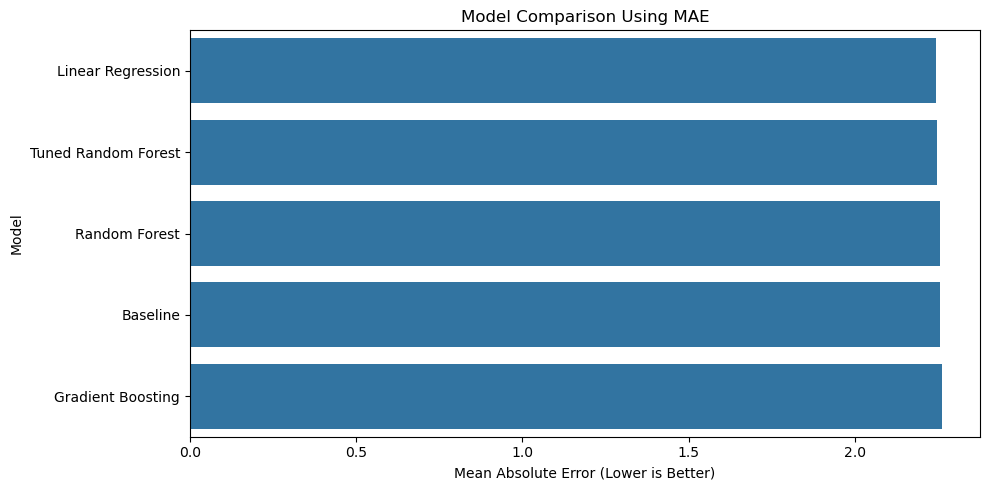

In [27]:
## Compare MAE across all models
plt.figure(figsize=(10, 5))

sns.barplot(
    data=final_results,
    x="MAE",
    y="Model"
)

plt.title("Model Comparison Using MAE")
plt.xlabel("Mean Absolute Error (Lower is Better)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


### Model Comparison Interpretation

The bars are visually almost identical — the tuned model improves MAE by only
0.46% and RMSE by 0.3% over the
baseline. This supports the conclusion that the weak results are caused by
limited predictive relationships in the dataset itself, rather than by the
choice of algorithm: no amount of model sophistication can substitute for
signal that isn't present in the features.

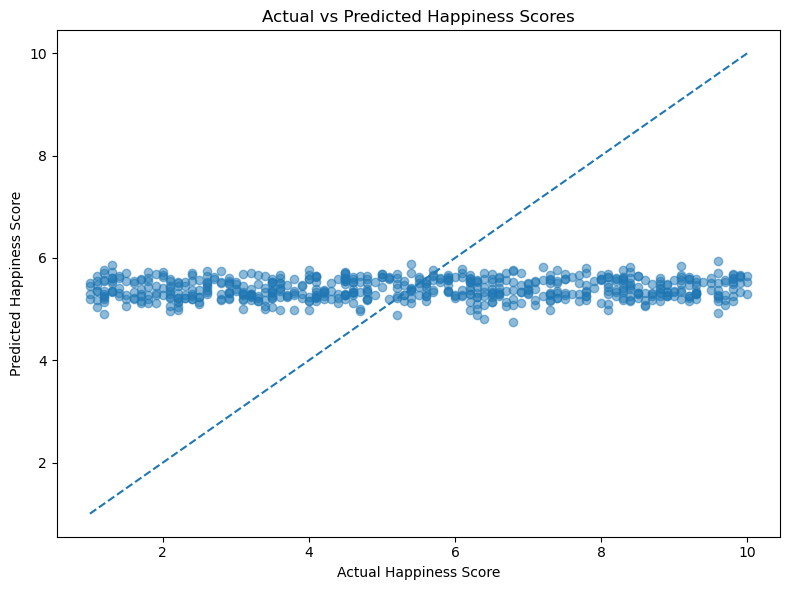

In [28]:
## Compare actual and predicted Happiness Scores
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.5
)

minimum_value = min(y_test.min(), tuned_predictions.min())
maximum_value = max(y_test.max(), tuned_predictions.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Happiness Scores")
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.tight_layout()
plt.show()


### Actual Versus Predicted Values

A strong regression model would produce points hugging the diagonal
reference line. Here, actual scores have a standard deviation of
2.60, but predictions have a standard deviation of only
0.20 — the model's predictions are compressed into a narrow
band around the overall mean rather than spreading out to match the real
range of scores. This is the visual signature of a model that has correctly
learned "the safest guess is close to the average" because the inputs do not
reliably distinguish high-happiness from low-happiness individuals.

In [2]:
## Check the distribution of prediction errors
residuals = y_test - tuned_predictions

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual: Actual Score - Predicted Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


NameError: name 'y_test' is not defined

### Residual Interpretation

Residuals are centred almost exactly on zero (mean = 0.0098), so the
model is not systematically biased high or low. However, the residual
standard deviation (2.60) is nearly as large as the standard
deviation of the actual scores themselves (2.60) — meaning the
model's errors are almost as large as the natural spread of the data it is
trying to predict. This is consistent with the low R² score and confirms
that the available features have limited ability to explain the target.

In [30]:
## Save the final trained model
import joblib

joblib.dump(
    tuned_model,
    "happiness_prediction_model.pkl"
)

print("Model saved successfully.")


Model saved successfully.


### Model Export

The complete tuned pipeline was saved as
`happiness_prediction_model.pkl`.

The exported object contains both preprocessing and model-prediction steps.
This allows the Streamlit application to accept raw user inputs and apply the
same transformations used during model training.